In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("valakhorasani/gym-members-exercise-dataset")

print("Path to dataset files:", path)

c:\Users\yamaw\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\yamaw\.cache\kagglehub\datasets\valakhorasani\gym-members-exercise-dataset\versions\1


In [3]:
import pandas as pd
import os

files = os.listdir(path)
print(files)

csv_path = os.path.join(path, files[0])
df = pd.read_csv(csv_path)

df.head()

['gym_members_exercise_tracking.csv']


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [4]:
# 列名を日本語に変換
name_map = {
    "Age": "年齢",
    "Gender": "性別",
    "Weight (kg)": "身長_m",
    "Height (m)": "体重_kg",
    "Max_BPM": "最大心拍数",
    "Avg_BPM": "平均心拍数",
    "Resting_BPM": "安静時心拍数",
    "Session_Duration (hours)": "運動時間_h",
    "Calories_Burned": "消費カロリー",
    "Workout_Type": "ワークアウト種別",
    "Fat_Percentage": "体脂肪率",
    "Water_Intake (liters)": "水分摂取量_l",
    "Workout_Frequency (days/week)": "運動頻度_週",
    "Experience_Level": "経験レベル",
    "BMI": "BMI"
}

# 書き換え
df = df.rename(columns=name_map)
df.head()

,年齢,性別,身長_m,体重_kg,最大心拍数,平均心拍数,安静時心拍数,運動時間_h,消費カロリー,ワークアウト種別,体脂肪率,水分摂取量_l,運動頻度_週,経験レベル,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   年齢        973 non-null    int64  
 1   性別        973 non-null    object 
 2   身長_m      973 non-null    float64
 3   体重_kg     973 non-null    float64
 4   最大心拍数     973 non-null    int64  
 5   平均心拍数     973 non-null    int64  
 6   安静時心拍数    973 non-null    int64  
 7   運動時間_h    973 non-null    float64
 8   消費カロリー    973 non-null    float64
 9   ワークアウト種別  973 non-null    object 
 10  体脂肪率      973 non-null    float64
 11  水分摂取量_l   973 non-null    float64
 12  運動頻度_週    973 non-null    int64  
 13  経験レベル     973 non-null    int64  
 14  BMI       973 non-null    float64
dtypes: float64(7), int64(6), object(2)
memory usage: 114.2+ KB


In [6]:
# 性別を０と１に変換（{"Male": 0, "Female": 1}）
df["性別"] = df["性別"].replace({"Male": 0, "Female": 1}).astype(int)

# ワークアウト種別をOne-Hot-Encoding
df = pd.get_dummies(df, columns=["ワークアウト種別"])

# 結果確認
df.head()

C:\Users\yamaw\AppData\Local\Temp\ipykernel_6288\532475140.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["性別"] = df["性別"].replace({"Male": 0, "Female": 1}).astype(int)


,年齢,性別,身長_m,体重_kg,最大心拍数,平均心拍数,安静時心拍数,運動時間_h,消費カロリー,体脂肪率,水分摂取量_l,運動頻度_週,経験レベル,BMI,ワークアウト種別_Cardio,ワークアウト種別_HIIT,ワークアウト種別_Strength,ワークアウト種別_Yoga
0,56,0,88.3,1.71,180,157,60,1.69,1313.0,12.6,3.5,4,3,30.20,False,False,False,True
1,46,1,74.9,1.53,179,151,66,1.30,883.0,33.9,2.1,4,2,32.00,False,True,False,False
2,32,1,68.1,1.66,167,122,54,1.11,677.0,33.4,2.3,4,2,24.71,True,False,False,False
3,25,0,53.2,1.70,190,164,56,0.59,532.0,28.8,2.1,3,1,18.41,False,False,True,False
4,38,0,46.1,1.79,188,158,68,0.64,556.0,29.2,2.8,3,1,14.39,False,False,True,False


In [7]:
from sklearn.preprocessing import StandardScaler

# 数値データの列だけを選択
# 「消費カロリー」は予測ターゲット（答え）なので、それ以外を正規化する
target = "消費カロリー"
features = df.columns.drop(target)

scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

df.head()

,年齢,性別,身長_m,体重_kg,最大心拍数,平均心拍数,安静時心拍数,運動時間_h,消費カロリー,体脂肪率,水分摂取量_l,運動頻度_週,経験レベル,BMI,ワークアウト種別_Cardio,ワークアウト種別_HIIT,ワークアウト種別_Strength,ワークアウト種別_Yoga
0,1.422343,-0.950847,0.681493,-0.098545,0.010081,0.922970,-0.303555,1.264598,1313.0,-1.978321,1.455967,0.743295,1.609784,0.794278,-0.595947,-0.542110,-0.600699,1.752464
1,0.600965,1.051694,0.049316,-1.508604,-0.076726,0.504494,0.515749,0.127098,883.0,1.426301,-0.877898,0.743295,0.257176,1.064652,-0.595947,1.844645,-0.600699,-0.570625
2,-0.548964,1.051694,-0.271491,-0.490228,-1.118414,-1.518142,-1.122858,-0.427068,677.0,1.346380,-0.544488,0.743295,0.257176,-0.030361,1.678001,-0.542110,-0.600699,-0.570625
3,-1.123928,-0.950847,-0.974433,-0.176881,0.878155,1.411193,-0.849757,-1.943735,532.0,0.611110,-0.877898,-0.352502,-1.095432,-0.976669,-0.595947,-0.542110,1.664728,-0.570625
4,-0.056137,-0.950847,-1.309393,0.528148,0.704540,0.992716,0.788850,-1.797902,556.0,0.675047,0.289035,-0.352502,-1.095432,-1.580503,-0.595947,-0.542110,1.664728,-0.570625


In [8]:
from sklearn.model_selection import train_test_split

# 特徴量（X）と目的変数（ｙ）に分ける
X = df.drop("消費カロリー", axis=1)
y = df["消費カロリー"]

# 学習用とテスト用に分割（20%をテストにする）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"学習用データの数：{len(X_train)}件")
print(f"テスト用データの数：{len(X_test)}件")

学習用データの数：778件
テスト用データの数：195件


In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# モデルの作成
model = RandomForestRegressor(random_state=42)

# 学習
model.fit(X_train, y_train)

# 予測
y_pred = model.predict(X_test)

# 評価
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE（平均誤差）: {rmse:.2f}")
print(f"R2 Score（決定係数）: {r2:.4f}")

RMSE（平均誤差）: 47.62
R2 Score（決定係数）: 0.9728


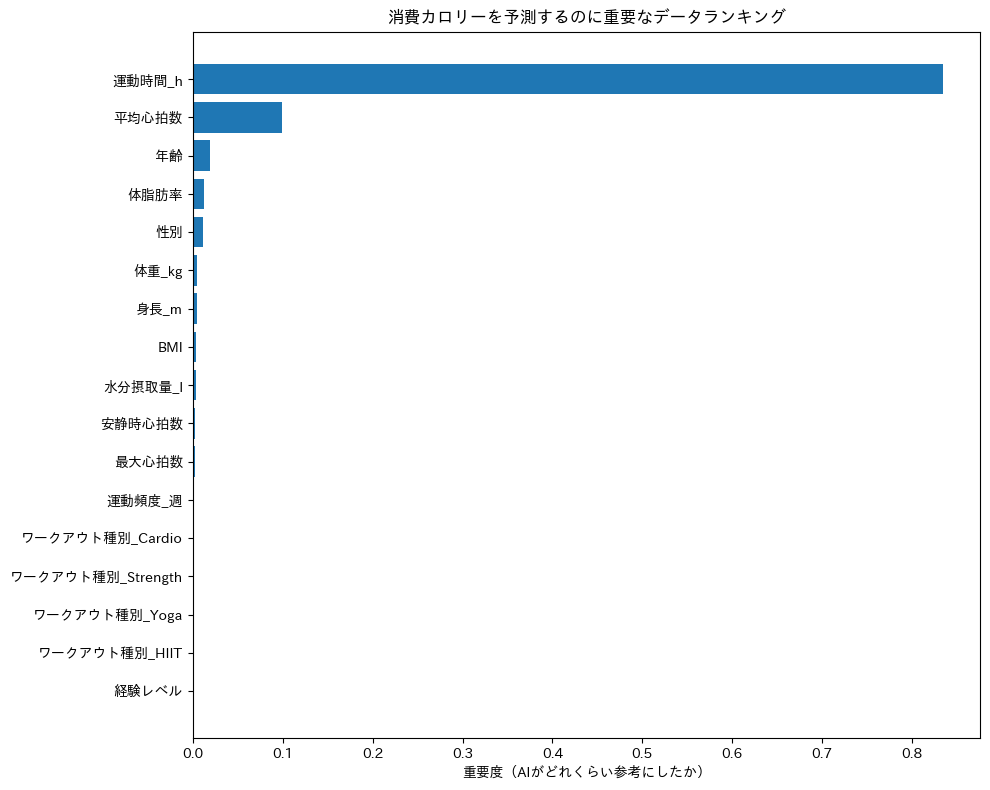

In [14]:
from matplotlib.lines import lineStyles
import matplotlib.pyplot as plt
import japanize_matplotlib

# 特徴量と重要度を取得
importances = model.feature_importances_
feature_names = X.columns
sorted_idx = importances.argsort()

# グラフ作成
plt.figure(figsize=(10, 8))
plt.barh(feature_names[sorted_idx], importances[sorted_idx])
plt.xlabel("重要度（AIがどれくらい参考にしたか）")
plt.title("消費カロリーを予測するのに重要なデータランキング")

plt.tight_layout()
plt.show()

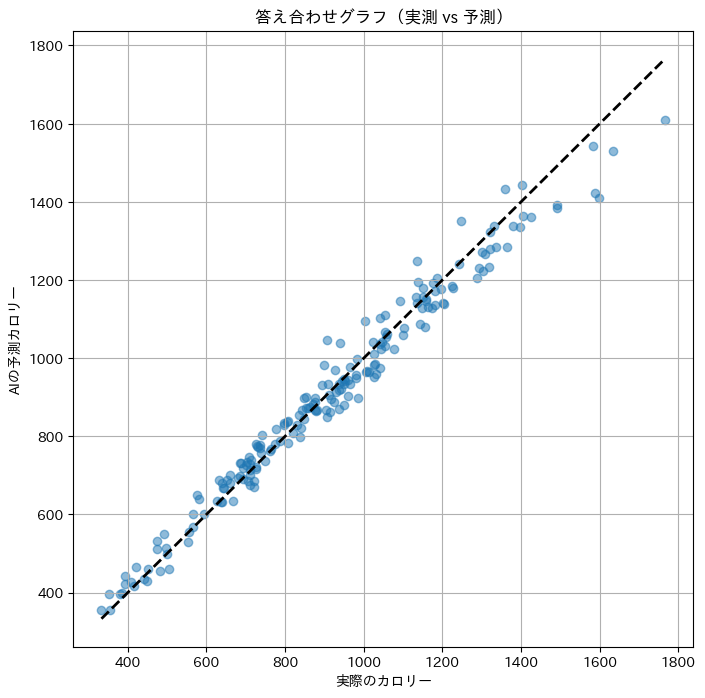

In [15]:
import matplotlib.pyplot as plt

# テストデータの予測値
y_pred = model.predict(X_test)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=2)
plt.xlabel("実際のカロリー")
plt.ylabel("AIの予測カロリー")
plt.title("答え合わせグラフ（実測 vs 予測）")
plt.grid(True)
plt.show()
